# Credit Card Fraud Detection

## Part 01 — Data Audit & Class Imbalance Baseline

## Project Goal

This project focuses on detecting fraudulent credit card transactions in a highly imbalanced dataset.

Only a very small number of transactions are fraudulent, so accuracy alone is not a good measure of model performance. The project will compare different ways of handling class imbalance, evaluate models using fraud-focused metrics, and tune the final decision threshold based on business costs.

## Part 01

The first step is to understand the dataset and the class imbalance before building any machine learning models.

This includes:

- checking the structure and quality of the data
- looking at the distribution of legitimate and fraudulent transactions
- calculating the fraud rate
- creating a naive baseline
- understanding why accuracy is misleading for this problem
- introducing the metrics that will be used later

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import precision_score, recall_score, f1_score

## Load the Dataset

In [2]:
df = pd.read_csv("../data/raw/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Dataset Overview

The dataset contains credit card transactions with anonymized numerical features.

The `Class` column is the target variable:

- `0` = legitimate transaction
- `1` = fraudulent transaction

The `V1` to `V28` columns are anonymized transaction features. Their individual business meanings are not provided in the dataset.

`Time` represents the time elapsed between transactions, while `Amount` represents the transaction amount.

## Initial Data Inspection

In [3]:
df.shape

(284807, 31)

In [4]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [5]:
df.dtypes

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

### Missing Values

In [6]:
df.isnull().sum().sum()

np.int64(0)

In [7]:
df.duplicated().sum()

np.int64(1081)

## Fraud Class Distribution

The main problem in this dataset is the severe imbalance between legitimate and fraudulent transactions.

The `Class` column is the target that we are trying to predict.

In [8]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [9]:
df["Class"].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

In [10]:
df["Class"].value_counts(normalize=True).mul(100).round(2)

Class
0    99.83
1     0.17
Name: proportion, dtype: float64

### Class Imbalance Finding

There are 284,315 legitimate transactions and only 492 fraudulent transactions.

Fraudulent transactions make up approximately 0.17% of the dataset, while legitimate transactions make up approximately 99.83%.

This is a severe class imbalance. A model could achieve very high accuracy by predicting almost every transaction as legitimate while still missing most or all fraudulent transactions.

## Visualizing the Class Imbalance

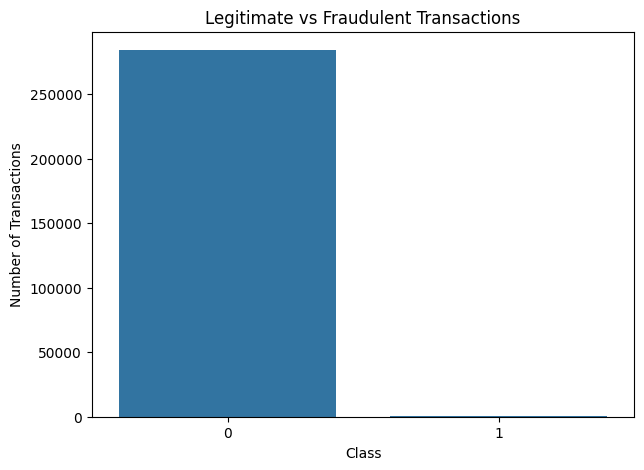

In [11]:
class_counts = df["Class"].value_counts()

plt.figure(figsize=(7, 5))
sns.barplot(x=class_counts.index, y=class_counts.values)

plt.title("Legitimate vs Fraudulent Transactions")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")
plt.savefig("../images/1_class_distribution.png")
plt.show()

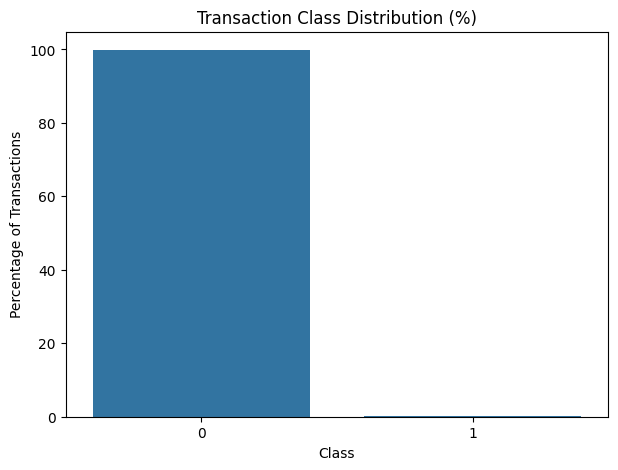

In [12]:
class_percentages = df["Class"].value_counts(normalize=True) * 100

plt.figure(figsize=(7, 5))
sns.barplot(x=class_percentages.index, y=class_percentages.values)

plt.title("Transaction Class Distribution (%)")
plt.xlabel("Class")
plt.ylabel("Percentage of Transactions")
plt.savefig("../images/2_class_distribution_percentage.png")
plt.show()

## Naive Baseline

Before building a machine learning model, it is useful to create a very simple baseline.

Because legitimate transactions make up almost the entire dataset, we can create a naive classifier that predicts every transaction as legitimate.

This baseline is intentionally simple. Its purpose is to show why accuracy can be misleading when the target classes are highly imbalanced.

In [13]:
baseline_predictions = np.zeros(len(df), dtype=int)
baseline_accuracy = (baseline_predictions == df["Class"]).mean()
baseline_accuracy

np.float64(0.9982725143693799)

In [14]:
baseline_accuracy * 100

np.float64(99.82725143693798)

### Baseline Fraud Metrics

In [15]:
baseline_precision = precision_score(
    df["Class"],
    baseline_predictions,
    zero_division=0
)

baseline_recall = recall_score(
    df["Class"],
    baseline_predictions,
    zero_division=0
)

baseline_f1 = f1_score(
    df["Class"],
    baseline_predictions,
    zero_division=0
)

baseline_precision, baseline_recall, baseline_f1

(0.0, 0.0, 0.0)

The naive baseline has 0 precision, 0 recall and 0 F1-score for the fraud class because it does not predict any transactions as fraudulent.

This makes the limitation of accuracy even clearer. Although the baseline achieves approximately 99.83% accuracy, it completely fails to identify fraud.

### Why Accuracy Is Misleading

The naive baseline achieves approximately 99.83% accuracy by predicting every transaction as legitimate.

However, this model detects no fraudulent transactions at all.

This shows that accuracy is not enough for this problem. A fraud detection model must be evaluated based on how well it identifies the rare fraudulent transactions, not just how many predictions it gets correct overall.

## Evaluation Metrics

Because fraud is the positive class, the main metrics need to focus on how well the model identifies fraudulent transactions.

### Precision

Precision answers:

"Of the transactions predicted as fraud, how many were actually fraud?"

A high precision means the model does not generate too many false fraud alerts.

### Recall

Recall answers:

"Of all the actual fraudulent transactions, how many did the model find?"

A high recall means fewer fraudulent transactions are missed.

### F1-score

F1-score combines precision and recall into a single metric.

It is useful when both false positives and false negatives matter.

### ROC-AUC

ROC-AUC measures how well the model separates the two classes across different classification thresholds.

### PR-AUC

PR-AUC summarizes the relationship between precision and recall across different thresholds.

For this project, PR-AUC is especially useful because the fraud class is extremely rare.

## False Positives and False Negatives

In fraud detection, there are two important types of mistakes.

A false positive happens when a legitimate transaction is incorrectly flagged as fraud.

A false negative happens when a fraudulent transaction is incorrectly classified as legitimate.

Both matter, but they have different business consequences. Missing a fraudulent transaction can result in financial loss, while incorrectly blocking a legitimate transaction can create a poor customer experience.

The later stages of the project will use this trade-off when choosing the final classification threshold.

## Class Distribution Summary

In [16]:
class_summary = pd.DataFrame({
    "Transaction Type": ["Legitimate", "Fraud"],
    "Count": [
        (df["Class"] == 0).sum(),
        (df["Class"] == 1).sum()
    ],
    "Percentage": [
        (df["Class"] == 0).mean() * 100,
        (df["Class"] == 1).mean() * 100
    ]
})

class_summary

,Transaction Type,Count,Percentage
0,Legitimate,284315,99.827251
1,Fraud,492,0.172749


In [17]:
class_summary["Percentage"] = class_summary["Percentage"].round(2)
class_summary

,Transaction Type,Count,Percentage
0,Legitimate,284315,99.83
1,Fraud,492,0.17


## Part 01 Findings

The dataset contains 284,807 transactions across 31 columns.

There are 284,315 legitimate transactions and 492 fraudulent transactions. Fraud represents only 0.17% of all transactions.

The class distribution is therefore highly imbalanced.

A naive model that predicts every transaction as legitimate achieves approximately 99.83% accuracy but detects zero fraudulent transactions. This confirms that accuracy alone would give a misleading view of model performance.

For the rest of the project, precision, recall, F1-score, ROC-AUC, and PR-AUC will provide a more useful way to evaluate fraud detection models.

# Part 02 — Leakage-Safe Preprocessing & Pipeline Setup

### Goal

The next step is to prepare the data for machine learning without allowing information from the test set to influence the training process.

The features and target will be separated first, followed by a stratified train/test split. A preprocessing pipeline will then be created so that transformations are fitted only on training data.

An imbalanced-learn pipeline will also be introduced so that future resampling methods can be applied only during model training and cross-validation.

## Separate Features and Target

In [18]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [19]:
X.shape, y.shape

((284807, 30), (284807,))

The target column `Class` has been separated from the transaction features.

There are 30 input features and 284,807 target values.

## Train-Test Split

The data will be divided into training and test sets using an 80/20 split.

Stratification is used so that the very small fraud class remains represented in both sets at approximately the same rate.

The test set will be kept separate from preprocessing, resampling, and model training.

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [22]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((227845, 30), (56962, 30), (227845,), (56962,))

### Checking the Class Distribution After the Split

In [23]:
y_train.value_counts()

Class
0    227451
1       394
Name: count, dtype: int64

In [24]:
y_test.value_counts()

Class
0    56864
1       98
Name: count, dtype: int64

In [25]:
y_train.value_counts(normalize=True) * 100

Class
0    99.827075
1     0.172925
Name: proportion, dtype: float64

In [26]:
y_test.value_counts(normalize=True) * 100

Class
0    99.827955
1     0.172045
Name: proportion, dtype: float64

### Split Check

The stratified split keeps the class distribution approximately the same in both the training and test sets.

The fraud class remains around 0.17% in both sets.

The test set will now be kept untouched while preprocessing, resampling, and model training are performed using the training data.

## Preprocessing Pipeline

The preprocessing step will be placed inside a pipeline instead of being applied manually to the full dataset.

This means the scaler will learn its values from the training data when the pipeline is fitted. The test data will only be transformed using the values learned from training data.

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

preprocessing_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

In [28]:
preprocessing_pipeline

,steps,"[('scaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True


In [29]:
preprocessing_pipeline.fit(X_train)

,steps,"[('scaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True


In [30]:
X_train_scaled = preprocessing_pipeline.transform(X_train)
X_test_scaled = preprocessing_pipeline.transform(X_test)

In [31]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler

## Imbalanced-Learn Pipeline

An imbalanced-learn pipeline allows preprocessing, resampling, and a model to be treated as one workflow.

The important part is that the resampling step will only be performed when the pipeline is fitted on training data.

This prevents the test set from being resampled and helps prevent leakage during cross-validation.

In [32]:
imbalance_pipeline = ImbPipeline([
    ("scaler", StandardScaler()),
    ("sampler", RandomUnderSampler(random_state=42))
])

## Why the Pipeline Matters

Resampling should never be performed on the full dataset before cross-validation.

For example, applying SMOTE to the entire dataset before creating training and validation folds could allow synthetic examples to contain information derived from observations that later appear in the validation fold.

The imbalanced-learn pipeline avoids this by applying the resampling step only when the training portion of each fold is fitted.

The test set remains completely untouched until final model evaluation.

# Part 03 — Imbalance Strategy Comparison

## Goal

The fraud class is extremely rare, so the model needs a way to handle the class imbalance.

Three strategies will be compared using the same Logistic Regression model:

- class weighting
- random undersampling
- SMOTE oversampling

The comparison will use precision, recall, F1-score, ROC-AUC and PR-AUC.

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

## Baseline Model

Logistic Regression will be used for this comparison.

Using the same model for all three strategies makes it easier to see the effect of the imbalance-handling method itself.

The goal of this stage is not to find the best possible model yet. That will be handled in the later model comparison and tuning stages.

## Cross-Validation

The three strategies will be compared using stratified 5-fold cross-validation on the training data.

The test set will remain untouched until the final evaluation stage.

Stratification is used because the fraud class is very small.

In [34]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

## Evaluation Metrics

Each strategy will be evaluated using five metrics.

Precision measures how many transactions predicted as fraud are actually fraudulent.

Recall measures how many of the actual fraudulent transactions are detected.

F1-score combines precision and recall.

ROC-AUC measures how well the model separates the two classes across thresholds.

PR-AUC is especially useful for this problem because the fraud class is extremely rare.

In [35]:
scoring = {
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

### 1. Class Weighting

In [36]:
class_weight_pipeline = ImbPipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

### 2. Random Undersampling

In [37]:
undersampling_pipeline = ImbPipeline([
    ("scaler", StandardScaler()),
    ("sampler", RandomUnderSampler(random_state=42)),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

### 3. SMOTE Oversampling

In [38]:
smote_pipeline = ImbPipeline([
    ("scaler", StandardScaler()),
    ("sampler", SMOTE(random_state=42)),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

## Why the Resampling Is Safe

The resampling methods are inside the imbalanced-learn pipelines.

This means that during cross-validation, each resampling method is applied only to the training portion of each fold.

The validation portion is not resampled.

The separate test set is also not resampled.

This prevents information from the validation or test data from leaking into model training.

In [39]:
class_weight_results = cross_validate(
    class_weight_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)
class_weight_results

{'fit_time': array([1.46457505, 1.40342832, 1.3317914 , 1.59607172, 1.55918884]),
 'score_time': array([0.06494403, 0.09052491, 0.07548451, 0.05963445, 0.06519103]),
 'test_precision': array([0.06053068, 0.06635945, 0.06686047, 0.05723125, 0.06299213]),
 'test_recall': array([0.93589744, 0.91139241, 0.87341772, 0.93670886, 0.91139241]),
 'test_f1': array([0.11370717, 0.12371134, 0.12421242, 0.10787172, 0.11783961]),
 'test_roc_auc': array([0.99263619, 0.98091694, 0.96802914, 0.99504189, 0.97579577]),
 'test_pr_auc': array([0.8166403 , 0.75839613, 0.67411864, 0.80626469, 0.73026067])}

In [40]:
class_weight_summary = {
    "Strategy": "Class Weighting",
    "Precision": class_weight_results["test_precision"].mean(),
    "Recall": class_weight_results["test_recall"].mean(),
    "F1": class_weight_results["test_f1"].mean(),
    "ROC-AUC": class_weight_results["test_roc_auc"].mean(),
    "PR-AUC": class_weight_results["test_pr_auc"].mean()
}

class_weight_summary

{'Strategy': 'Class Weighting',
 'Precision': np.float64(0.06279479264101687),
 'Recall': np.float64(0.9137617656604998),
 'F1': np.float64(0.1174684507750543),
 'ROC-AUC': np.float64(0.9824839842147348),
 'PR-AUC': np.float64(0.7571360842475147)}

In [41]:
class_weight_results["test_precision"].std()

np.float64(0.00361537441246607)

In [42]:
undersampling_results = cross_validate(
    undersampling_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [43]:
undersampling_summary = {
    "Strategy": "Random Undersampling",
    "Precision": undersampling_results["test_precision"].mean(),
    "Recall": undersampling_results["test_recall"].mean(),
    "F1": undersampling_results["test_f1"].mean(),
    "ROC-AUC": undersampling_results["test_roc_auc"].mean(),
    "PR-AUC": undersampling_results["test_pr_auc"].mean()
}

undersampling_summary

{'Strategy': 'Random Undersampling',
 'Precision': np.float64(0.036864700424215815),
 'Recall': np.float64(0.9163258682246024),
 'F1': np.float64(0.07082009831974043),
 'ROC-AUC': np.float64(0.9818096425597304),
 'PR-AUC': np.float64(0.6622638264704233)}

In [44]:
smote_results = cross_validate(
    smote_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [45]:
smote_summary = {
    "Strategy": "SMOTE",
    "Precision": smote_results["test_precision"].mean(),
    "Recall": smote_results["test_recall"].mean(),
    "F1": smote_results["test_f1"].mean(),
    "ROC-AUC": smote_results["test_roc_auc"].mean(),
    "PR-AUC": smote_results["test_pr_auc"].mean()
}

smote_summary

{'Strategy': 'SMOTE',
 'Precision': np.float64(0.05812636474895437),
 'Recall': np.float64(0.9188250567997404),
 'F1': np.float64(0.10930628267514975),
 'ROC-AUC': np.float64(0.9805452998769372),
 'PR-AUC': np.float64(0.7527513433898763)}

## Strategy Comparison

In [46]:
comparison = pd.DataFrame([
    class_weight_summary,
    undersampling_summary,
    smote_summary
])

comparison.round(4)

,Strategy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Class Weighting,0.0628,0.9138,0.1175,0.9825,0.7571
1,Random Undersampling,0.0369,0.9163,0.0708,0.9818,0.6623
2,SMOTE,0.0581,0.9188,0.1093,0.9805,0.7528


In [47]:
comparison_std = pd.DataFrame([
    {
        "Strategy": "Class Weighting",
        "Precision": class_weight_results["test_precision"].std(),
        "Recall": class_weight_results["test_recall"].std(),
        "F1": class_weight_results["test_f1"].std(),
        "ROC-AUC": class_weight_results["test_roc_auc"].std(),
        "PR-AUC": class_weight_results["test_pr_auc"].std()
    },
    {
        "Strategy": "Random Undersampling",
        "Precision": undersampling_results["test_precision"].std(),
        "Recall": undersampling_results["test_recall"].std(),
        "F1": undersampling_results["test_f1"].std(),
        "ROC-AUC": undersampling_results["test_roc_auc"].std(),
        "PR-AUC": undersampling_results["test_pr_auc"].std()
    },
    {
        "Strategy": "SMOTE",
        "Precision": smote_results["test_precision"].std(),
        "Recall": smote_results["test_recall"].std(),
        "F1": smote_results["test_f1"].std(),
        "ROC-AUC": smote_results["test_roc_auc"].std(),
        "PR-AUC": smote_results["test_pr_auc"].std()
    }
])

comparison_std.round(4)

,Strategy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Class Weighting,0.0036,0.0230,0.0062,0.0102,0.0521
1,Random Undersampling,0.0051,0.0271,0.0094,0.0101,0.0485
2,SMOTE,0.0031,0.0219,0.0054,0.0115,0.0483


## Imbalance Strategy Performance

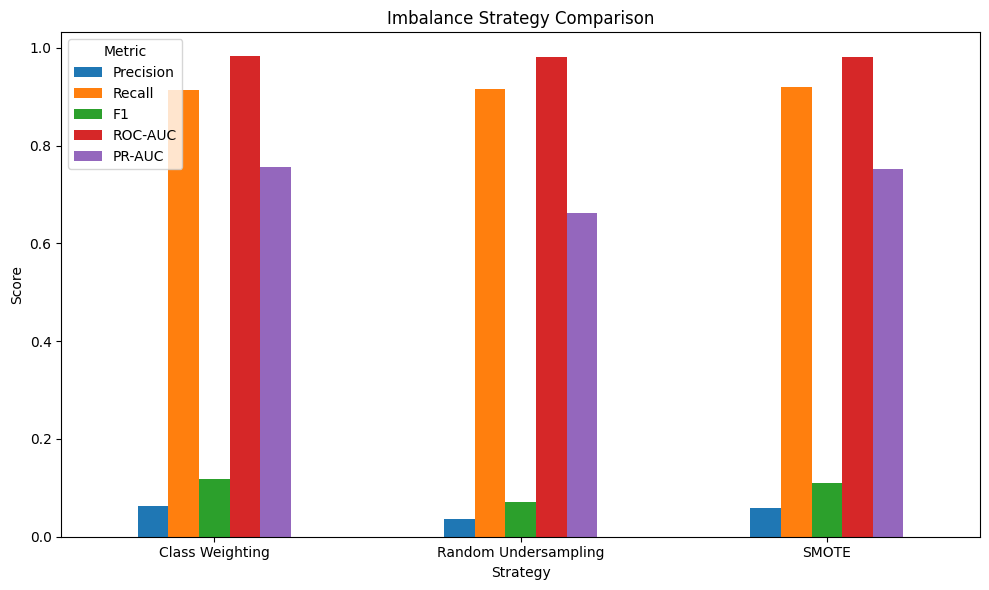

In [48]:
comparison_plot = comparison.set_index("Strategy")

comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Imbalance Strategy Comparison")
plt.xlabel("Strategy")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(title="Metric")

plt.tight_layout()
plt.savefig("../images/3_imbalance_strategy_comparison.png")
plt.show()

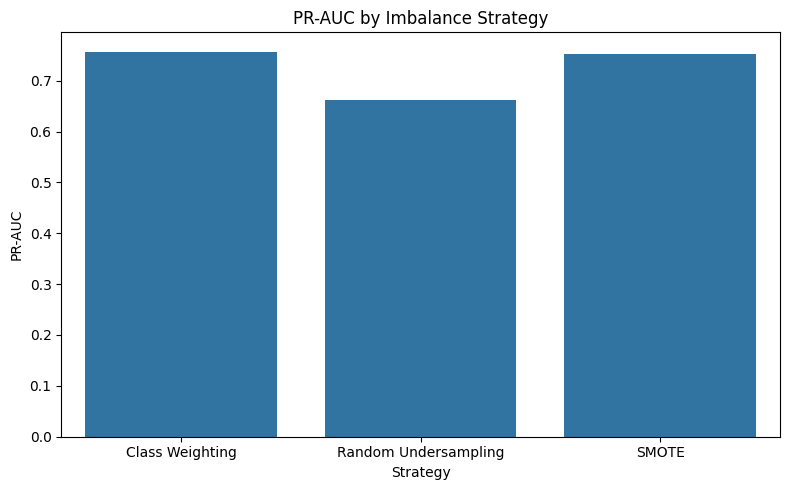

In [49]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparison,
    x="Strategy",
    y="PR-AUC"
)

plt.title("PR-AUC by Imbalance Strategy")
plt.xlabel("Strategy")
plt.ylabel("PR-AUC")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig("../images/4_pr_auc_by_strategy.png")
plt.show()

## Part 03 Findings

The three imbalance strategies produced different precision, recall, F1-score, ROC-AUC and PR-AUC results.

Class weighting achieved the highest precision (0.0628), F1-score (0.1175), ROC-AUC (0.9825) and PR-AUC (0.7571). Its recall was 0.9138.

Random undersampling achieved a recall of 0.9163, but it had the lowest precision (0.0369), F1-score (0.0708) and PR-AUC (0.6623) of the three strategies.

SMOTE achieved the highest recall at 0.9188. However, its precision (0.0581), F1-score (0.1093), ROC-AUC (0.9805) and PR-AUC (0.7528) were slightly lower than class weighting.

The main trade-off between the strategies was between identifying more fraudulent transactions and limiting false positive predictions.

PR-AUC was given particular attention because fraud represents only a very small proportion of all transactions.

Based on the cross-validation results, class weighting was the strongest overall strategy at this stage because it performed best on precision, F1-score, ROC-AUC and PR-AUC.

# Part 04 — Model Family Comparison

## Goal

The previous stage compared different ways of handling class imbalance using Logistic Regression.

This stage compares two different model families using the strongest imbalance strategy from Part 03: class weighting.

The models will be compared using precision, recall, F1-score, ROC-AUC and PR-AUC.

ROC and precision-recall curves will also be used to compare their ability to separate fraudulent transactions from legitimate ones.

In [50]:
from xgboost import XGBClassifier
from sklearn.model_selection import cross_validate, cross_val_predict
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)

In [51]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

scale_pos_weight

np.float64(577.2868020304569)

In [52]:
logistic_model = ImbPipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

In [53]:
xgb_model = ImbPipeline([
    ("model", XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    ))
])

In [54]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [55]:
model_scoring = {
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

In [56]:
logistic_results = cross_validate(
    logistic_model,
    X_train,
    y_train,
    cv=cv,
    scoring=model_scoring,
    n_jobs=-1
)

logistic_results

{'fit_time': array([0.7665081 , 1.17848778, 1.08655739, 1.28580546, 1.25369334]),
 'score_time': array([0.05562449, 0.05875134, 0.06983328, 0.05272412, 0.05028987]),
 'test_precision': array([0.06053068, 0.06635945, 0.06686047, 0.05723125, 0.06299213]),
 'test_recall': array([0.93589744, 0.91139241, 0.87341772, 0.93670886, 0.91139241]),
 'test_f1': array([0.11370717, 0.12371134, 0.12421242, 0.10787172, 0.11783961]),
 'test_roc_auc': array([0.99263619, 0.98091694, 0.96802914, 0.99504189, 0.97579577]),
 'test_pr_auc': array([0.8166403 , 0.75839613, 0.67411864, 0.80626469, 0.73026067])}

In [57]:
logistic_summary = {
    "Model": "Logistic Regression",
    "Precision": logistic_results["test_precision"].mean(),
    "Recall": logistic_results["test_recall"].mean(),
    "F1": logistic_results["test_f1"].mean(),
    "ROC-AUC": logistic_results["test_roc_auc"].mean(),
    "PR-AUC": logistic_results["test_pr_auc"].mean()
}

logistic_summary

{'Model': 'Logistic Regression',
 'Precision': np.float64(0.06279479264101687),
 'Recall': np.float64(0.9137617656604998),
 'F1': np.float64(0.1174684507750543),
 'ROC-AUC': np.float64(0.9824839842147348),
 'PR-AUC': np.float64(0.7571360842475147)}

In [58]:
xgb_results = cross_validate(
    xgb_model,
    X_train,
    y_train,
    cv=cv,
    scoring=model_scoring,
    n_jobs=-1
)

xgb_results

{'fit_time': array([7.224226  , 7.15999079, 7.05483222, 7.10936451, 7.11406398]),
 'score_time': array([0.22965908, 0.24115491, 0.26622605, 0.24695945, 0.26056576]),
 'test_precision': array([0.5112782 , 0.56140351, 0.46043165, 0.45283019, 0.52755906]),
 'test_recall': array([0.87179487, 0.81012658, 0.81012658, 0.91139241, 0.84810127]),
 'test_f1': array([0.64454976, 0.66321244, 0.58715596, 0.60504202, 0.65048544]),
 'test_roc_auc': array([0.99547163, 0.97754382, 0.97189339, 0.99503494, 0.98212905]),
 'test_pr_auc': array([0.82294328, 0.80880293, 0.74613272, 0.859527  , 0.77918069])}

In [59]:
xgb_summary = {
    "Model": "XGBoost",
    "Precision": xgb_results["test_precision"].mean(),
    "Recall": xgb_results["test_recall"].mean(),
    "F1": xgb_results["test_f1"].mean(),
    "ROC-AUC": xgb_results["test_roc_auc"].mean(),
    "PR-AUC": xgb_results["test_pr_auc"].mean()
}

xgb_summary

{'Model': 'XGBoost',
 'Precision': np.float64(0.5027005205468532),
 'Recall': np.float64(0.8503083414475819),
 'F1': np.float64(0.630089123053803),
 'ROC-AUC': np.float64(0.9844145664364176),
 'PR-AUC': np.float64(0.8033173241068358)}

In [60]:
model_comparison = pd.DataFrame([
    logistic_summary,
    xgb_summary
])

model_comparison.round(4)

,Model,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.0628,0.9138,0.1175,0.9825,0.7571
1,XGBoost,0.5027,0.8503,0.6301,0.9844,0.8033


In [61]:
model_comparison_std = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Precision": logistic_results["test_precision"].std(),
        "Recall": logistic_results["test_recall"].std(),
        "F1": logistic_results["test_f1"].std(),
        "ROC-AUC": logistic_results["test_roc_auc"].std(),
        "PR-AUC": logistic_results["test_pr_auc"].std()
    },
    {
        "Model": "XGBoost",
        "Precision": xgb_results["test_precision"].std(),
        "Recall": xgb_results["test_recall"].std(),
        "F1": xgb_results["test_f1"].std(),
        "ROC-AUC": xgb_results["test_roc_auc"].std(),
        "PR-AUC": xgb_results["test_pr_auc"].std()
    }
])

model_comparison_std.round(4)

,Model,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.0036,0.0230,0.0062,0.0102,0.0521
1,XGBoost,0.0410,0.0385,0.0290,0.0094,0.0385


In [62]:
logistic_probabilities = cross_val_predict(
    logistic_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

xgb_probabilities = cross_val_predict(
    xgb_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

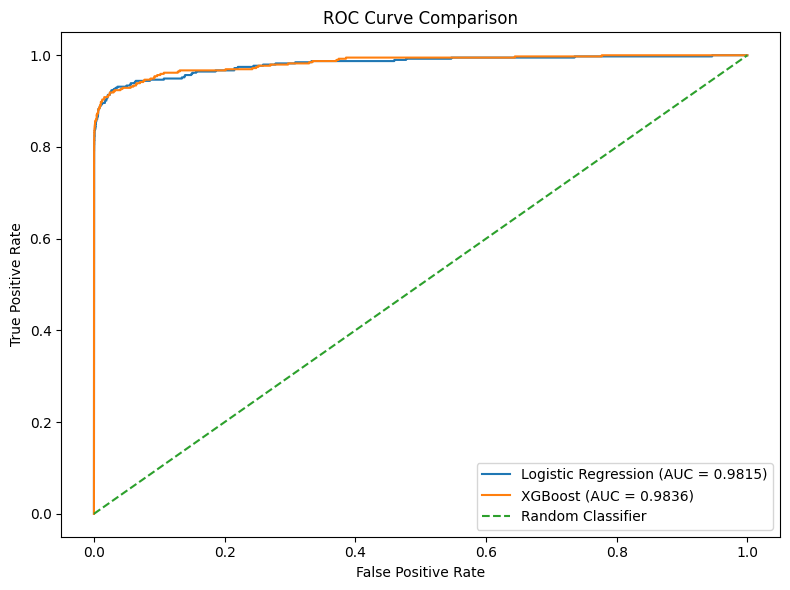

In [63]:
logistic_fpr, logistic_tpr, _ = roc_curve(
    y_train,
    logistic_probabilities
)

xgb_fpr, xgb_tpr, _ = roc_curve(
    y_train,
    xgb_probabilities
)

plt.figure(figsize=(8, 6))

plt.plot(
    logistic_fpr,
    logistic_tpr,
    label=f"Logistic Regression (AUC = {roc_auc_score(y_train, logistic_probabilities):.4f})"
)

plt.plot(
    xgb_fpr,
    xgb_tpr,
    label=f"XGBoost (AUC = {roc_auc_score(y_train, xgb_probabilities):.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

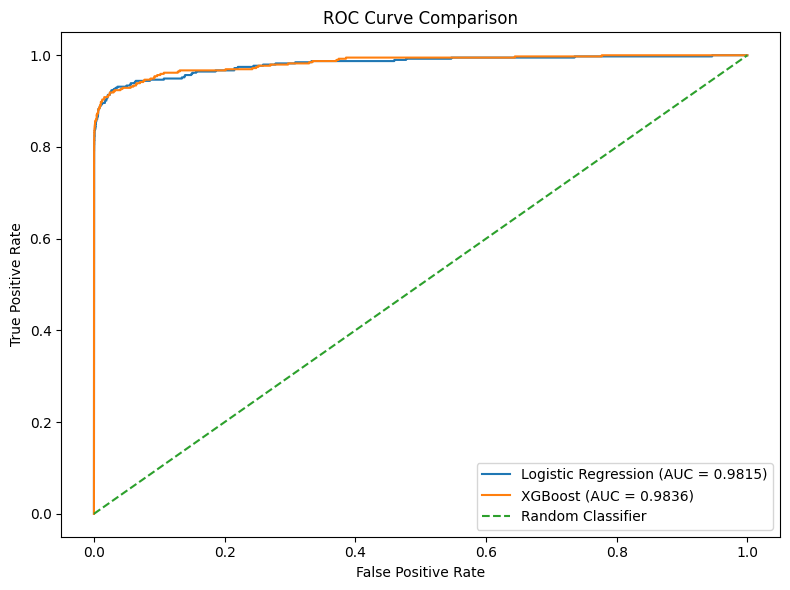

In [64]:
plt.figure(figsize=(8, 6))

plt.plot(
    logistic_fpr,
    logistic_tpr,
    label=f"Logistic Regression (AUC = {roc_auc_score(y_train, logistic_probabilities):.4f})"
)

plt.plot(
    xgb_fpr,
    xgb_tpr,
    label=f"XGBoost (AUC = {roc_auc_score(y_train, xgb_probabilities):.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()

plt.savefig(
    "../images/5_model_family_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

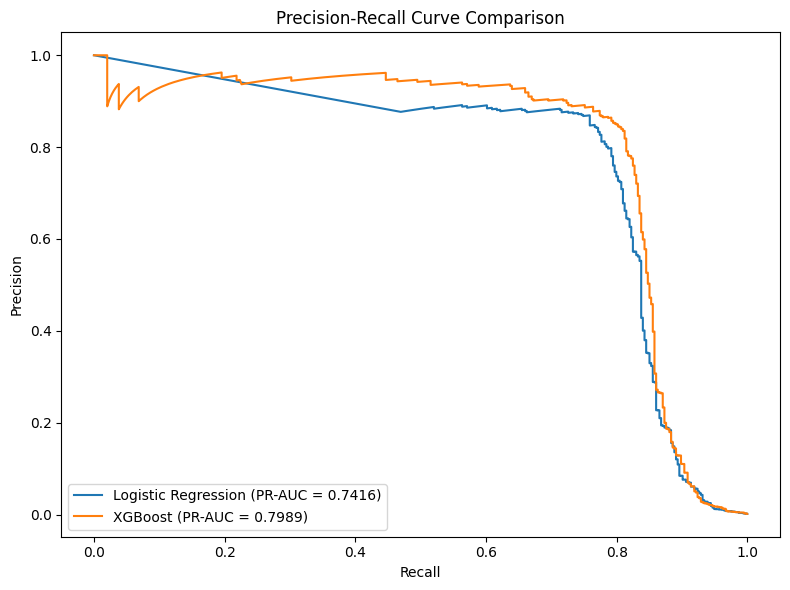

In [65]:
logistic_precision, logistic_recall, _ = precision_recall_curve(
    y_train,
    logistic_probabilities
)

xgb_precision, xgb_recall, _ = precision_recall_curve(
    y_train,
    xgb_probabilities
)

plt.figure(figsize=(8, 6))

plt.plot(
    logistic_recall,
    logistic_precision,
    label=f"Logistic Regression (PR-AUC = {average_precision_score(y_train, logistic_probabilities):.4f})"
)

plt.plot(
    xgb_recall,
    xgb_precision,
    label=f"XGBoost (PR-AUC = {average_precision_score(y_train, xgb_probabilities):.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

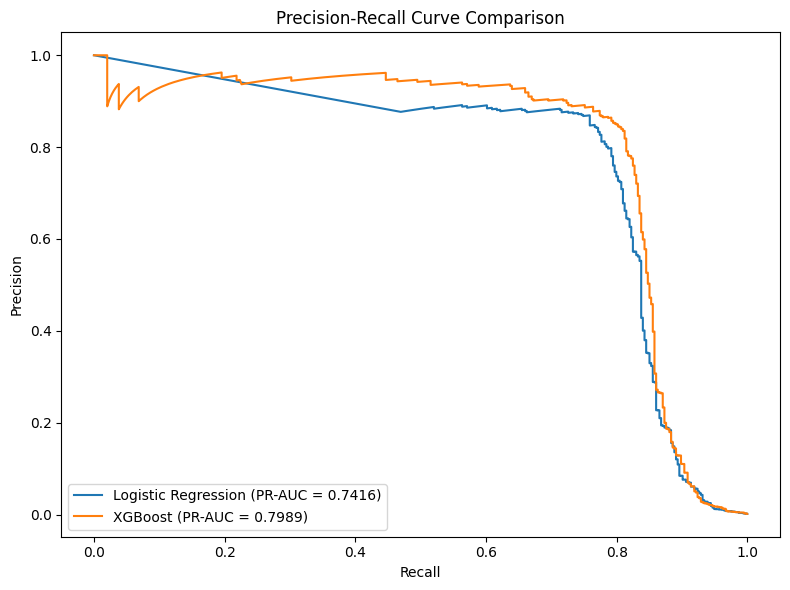

In [66]:
plt.figure(figsize=(8, 6))

plt.plot(
    logistic_recall,
    logistic_precision,
    label=f"Logistic Regression (PR-AUC = {average_precision_score(y_train, logistic_probabilities):.4f})"
)

plt.plot(
    xgb_recall,
    xgb_precision,
    label=f"XGBoost (PR-AUC = {average_precision_score(y_train, xgb_probabilities):.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.tight_layout()

plt.savefig(
    "../images/6_model_family_pr_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

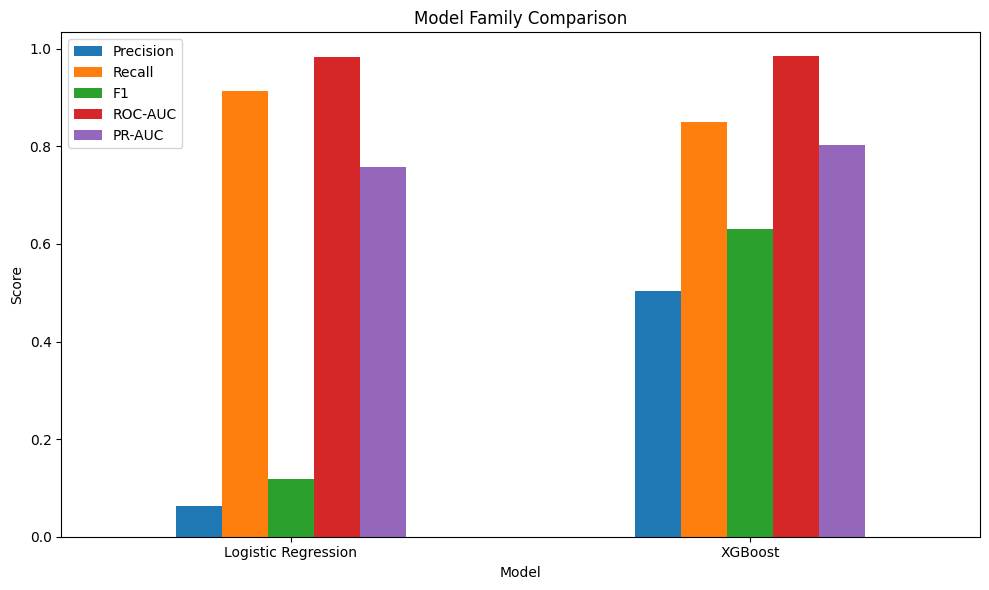

In [67]:
model_comparison_plot = model_comparison.set_index("Model")

model_comparison_plot[
    ["Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Family Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()

plt.savefig(
    "../images/7_model_family_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Part 04 Findings

Two different model families were compared: Logistic Regression and XGBoost.

Both models used the class-weighted approach identified as the strongest imbalance strategy in Part 03.

The models were evaluated using stratified 5-fold cross-validation on the training data.

Logistic Regression achieved a PR-AUC of 0.7571, while XGBoost achieved a PR-AUC of 0.8033.

XGBoost achieved much higher precision (0.5027) and F1-score (0.6301) than Logistic Regression, while Logistic Regression achieved higher recall (0.9138) than XGBoost (0.8503).

XGBoost also achieved slightly higher ROC-AUC (0.9844 versus 0.9825) and higher PR-AUC (0.8033 versus 0.7571).

The ROC and precision-recall curves showed stronger overall performance from XGBoost, especially in terms of precision-recall performance.

Based on the cross-validation results, XGBoost was the stronger model family at this stage because it achieved higher precision, F1-score, ROC-AUC and PR-AUC, while still maintaining a high recall.

The test set was not used for model selection and remains untouched for final evaluation.

# Part 05 — Cross-Validation & Model Tuning

## Goal

The previous stage showed that XGBoost performed better overall than Logistic Regression.

This stage tunes the model configurations using stratified cross-validation.

The candidate models will be compared using precision, recall, F1-score, ROC-AUC and PR-AUC, with particular attention given to PR-AUC.

The test set will remain untouched during tuning and model selection.

## Tuning Approach

The same class-weighted approach from the previous stages will be used.

Logistic Regression and XGBoost will each be given a small set of reasonable hyperparameter combinations.

Stratified 5-fold cross-validation will be used for every configuration.

PR-AUC will be used as the main metric for selecting the best configuration because fraud is extremely rare in the dataset.

In [68]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [69]:
tuning_scoring = {
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

In [70]:
logistic_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100]
}

In [71]:
logistic_grid_search = GridSearchCV(
    estimator=logistic_model,
    param_grid=logistic_param_grid,
    scoring=tuning_scoring,
    refit="pr_auc",
    cv=cv,
    n_jobs=-1
)

logistic_grid_search.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__C': [0.01, 0.1, ...]}"
,scoring,"{'f1': 'f1', 'pr_auc': 'average_precision', 'precision': 'precision', 'recall': 'recall', ...}"
,n_jobs,-1
,refit,'pr_auc'
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [72]:
print("Best Logistic Regression parameters:")
print(logistic_grid_search.best_params_)

print("\nBest Logistic Regression PR-AUC:")
print(round(logistic_grid_search.best_score_, 4))

Best Logistic Regression parameters:
{'model__C': 1}

Best Logistic Regression PR-AUC:
0.7571


In [73]:
logistic_cv_results = pd.DataFrame(
    logistic_grid_search.cv_results_
)

logistic_tuning_summary = logistic_cv_results[
    logistic_cv_results["rank_test_pr_auc"] == 1
][[
    "param_model__C",
    "mean_test_precision",
    "mean_test_recall",
    "mean_test_f1",
    "mean_test_roc_auc",
    "mean_test_pr_auc"
]]

logistic_tuning_summary.round(4)

,param_model__C,mean_test_precision,mean_test_recall,mean_test_f1,mean_test_roc_auc,mean_test_pr_auc
2,1.0,0.0628,0.9138,0.1175,0.9825,0.7571


In [74]:
xgb_param_distributions = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 4, 5],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

In [75]:
xgb_random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=xgb_param_distributions,
    n_iter=10,
    scoring=tuning_scoring,
    refit="pr_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

xgb_random_search.fit(X_train, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'model__colsample_bytree': [0.8, 1.0], 'model__learning_rate': [0.03, 0.05, ...], 'model__max_depth': [3, 4, ...], 'model__n_estimators': [100, 200, ...], ...}"
,n_iter,10
,scoring,"{'f1': 'f1', 'pr_auc': 'average_precision', 'precision': 'precision', 'recall': 'recall', ...}"
,n_jobs,-1
,refit,'pr_auc'
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [76]:
print("Best XGBoost parameters:")
print(xgb_random_search.best_params_)

print("\nBest XGBoost PR-AUC:")
print(round(xgb_random_search.best_score_, 4))

Best XGBoost parameters:
{'model__subsample': 1.0, 'model__n_estimators': 200, 'model__max_depth': 4, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.8}

Best XGBoost PR-AUC:
0.8345


In [77]:
xgb_cv_results = pd.DataFrame(
    xgb_random_search.cv_results_
)

xgb_tuning_summary = xgb_cv_results[
    xgb_cv_results["rank_test_pr_auc"] == 1
][[
    "param_model__n_estimators",
    "param_model__max_depth",
    "param_model__learning_rate",
    "param_model__subsample",
    "param_model__colsample_bytree",
    "mean_test_precision",
    "mean_test_recall",
    "mean_test_f1",
    "mean_test_roc_auc",
    "mean_test_pr_auc"
]]

xgb_tuning_summary.round(4)

,param_model__n_estimators,param_model__max_depth,param_model__learning_rate,param_model__subsample,param_model__colsample_bytree,mean_test_precision,mean_test_recall,mean_test_f1,mean_test_roc_auc,mean_test_pr_auc
7,200,4,0.1,1.0,0.8,0.7685,0.83,0.7967,0.9804,0.8345


In [78]:
tuned_model_comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Precision": logistic_tuning_summary["mean_test_precision"].iloc[0],
        "Recall": logistic_tuning_summary["mean_test_recall"].iloc[0],
        "F1": logistic_tuning_summary["mean_test_f1"].iloc[0],
        "ROC-AUC": logistic_tuning_summary["mean_test_roc_auc"].iloc[0],
        "PR-AUC": logistic_tuning_summary["mean_test_pr_auc"].iloc[0]
    },
    {
        "Model": "XGBoost",
        "Precision": xgb_tuning_summary["mean_test_precision"].iloc[0],
        "Recall": xgb_tuning_summary["mean_test_recall"].iloc[0],
        "F1": xgb_tuning_summary["mean_test_f1"].iloc[0],
        "ROC-AUC": xgb_tuning_summary["mean_test_roc_auc"].iloc[0],
        "PR-AUC": xgb_tuning_summary["mean_test_pr_auc"].iloc[0]
    }
])

tuned_model_comparison.round(4)

,Model,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.0628,0.9138,0.1175,0.9825,0.7571
1,XGBoost,0.7685,0.8300,0.7967,0.9804,0.8345


## Tuning Results

The tuned models were compared with the earlier model-family results.

The main purpose of tuning was to determine whether better hyperparameter settings could improve the cross-validated performance of either model.

PR-AUC was used as the main selection metric because the fraud class is extremely rare.

In [79]:
tuned_model_comparison.round(4)

,Model,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.0628,0.9138,0.1175,0.9825,0.7571
1,XGBoost,0.7685,0.8300,0.7967,0.9804,0.8345


In [80]:
previous_xgb_pr_auc = 0.8033

tuned_xgb_pr_auc = xgb_tuning_summary["mean_test_pr_auc"].iloc[0]

xgb_improvement = tuned_xgb_pr_auc - previous_xgb_pr_auc

print("Previous XGBoost PR-AUC:", previous_xgb_pr_auc)
print("Tuned XGBoost PR-AUC:", round(tuned_xgb_pr_auc, 4))
print("Change:", round(xgb_improvement, 4))

Previous XGBoost PR-AUC: 0.8033
Tuned XGBoost PR-AUC: 0.8345
Change: 0.0312


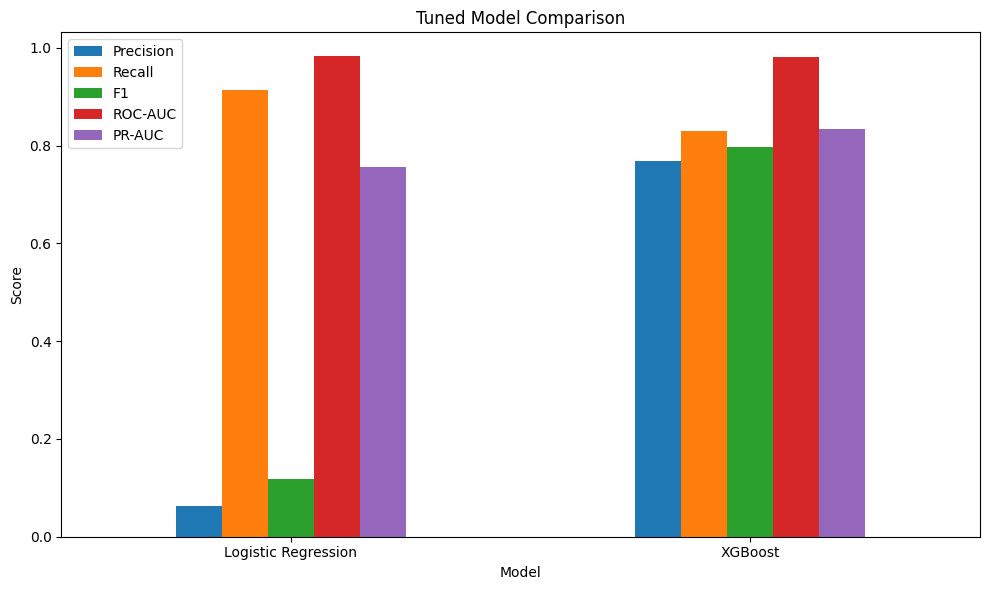

In [81]:
tuned_model_comparison.set_index("Model")[
    ["Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Tuned Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "../images/8_tuned_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [82]:
best_model = xgb_random_search.best_estimator_

## Part 05 Findings

Hyperparameter tuning was performed for Logistic Regression and XGBoost using stratified 5-fold cross-validation.

PR-AUC was used as the main model selection metric because the fraud class is extremely rare.

The best Logistic Regression configuration used C = 1 and achieved a PR-AUC of 0.7571.

The best XGBoost configuration used 200 estimators, a maximum tree depth of 4, a learning rate of 0.1, a subsample ratio of 1.0 and a column sampling ratio of 0.8. It achieved a PR-AUC of 0.8345.

Compared with the previous model-family comparison, tuning improved the XGBoost PR-AUC from 0.8033 to 0.8345.

The strongest tuned model was XGBoost based on the cross-validated results. It achieved much higher precision (0.7685), F1-score (0.7967) and PR-AUC (0.8345) than Logistic Regression, while Logistic Regression achieved higher recall (0.9138).

The selected XGBoost model will be used in the next stage for threshold tuning and business cost analysis.

The test set was not used during hyperparameter tuning or model selection and remains untouched.

# Part 06 — Threshold Tuning & Business Cost Analysis

## Goal

The previous stage selected XGBoost as the strongest model based on cross-validated PR-AUC.

This stage focuses on choosing a classification threshold rather than using the default 0.50 threshold.

The threshold will be selected by comparing the cost of missed fraud against the cost of incorrectly blocking legitimate transactions.

The test set will remain untouched until the final evaluation.

## Why Tune the Threshold?

The model produces a probability that a transaction is fraudulent.

A threshold converts that probability into a final prediction.

For example, with a threshold of 0.50:

- probability >= 0.50 → predict fraud
- probability < 0.50 → predict legitimate

Changing the threshold changes the number of false positives and false negatives.

For fraud detection, this trade-off matters because:

- a false positive may incorrectly block a legitimate customer
- a false negative may allow a fraudulent transaction to go through

The best threshold therefore depends on the relative business cost of these two errors.

In [83]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    precision_recall_curve,
    confusion_matrix
)

## Out-of-Fold Probabilities

The threshold should be selected without using the test set.

Out-of-fold predictions are used so that each training observation receives a prediction from a model that did not train on that observation.

This gives a more realistic set of probabilities for threshold selection.

In [84]:
xgb_oof_probabilities = cross_val_predict(
    best_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

In [85]:
from sklearn.metrics import average_precision_score

oof_pr_auc = average_precision_score(
    y_train,
    xgb_oof_probabilities
)

print("Out-of-fold PR-AUC:", round(oof_pr_auc, 4))

Out-of-fold PR-AUC: 0.8331


## Precision-Recall Curve

The precision-recall curve shows how precision and recall change as the classification threshold changes.

A lower threshold generally catches more fraud but can produce more false positive alerts.

A higher threshold generally reduces false positives but can miss more fraudulent transactions.

In [86]:
precision, recall, thresholds = precision_recall_curve(
    y_train,
    xgb_oof_probabilities
)

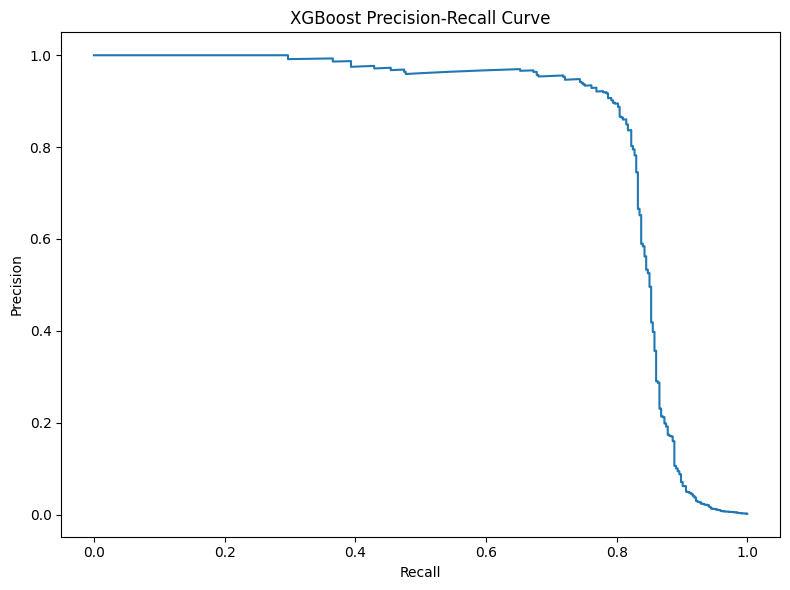

In [87]:
plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("XGBoost Precision-Recall Curve")
plt.tight_layout()

plt.savefig(
    "../images/9_xgb_precision_recall_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Business Cost Assumptions

Because the dataset does not provide actual business costs, illustrative cost values are used for this analysis.

The assumptions are:

- missed fraud (false negative) = 100 cost units
- incorrectly blocked legitimate transaction (false positive) = 5 cost units

This means a missed fraudulent transaction is treated as 20 times more costly than incorrectly blocking a legitimate transaction.

These values are only used to demonstrate cost-aware threshold selection. In a real fraud detection system, the costs would be estimated from actual fraud losses, investigation costs, customer impact and operational data.

In [88]:
cost_false_negative = 100
cost_false_positive = 5

In [89]:
thresholds_to_test = np.arange(0.01, 1.00, 0.01)

In [90]:
threshold_results = []

for threshold in thresholds_to_test:

    y_pred = (
        xgb_oof_probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_train,
        y_pred,
        labels=[0, 1]
    ).ravel()

    total_cost = (
        fp * cost_false_positive
        + fn * cost_false_negative
    )

    threshold_results.append({
        "Threshold": threshold,
        "True Negatives": tn,
        "False Positives": fp,
        "False Negatives": fn,
        "True Positives": tp,
        "Precision": tp / (tp + fp) if (tp + fp) > 0 else 0,
        "Recall": tp / (tp + fn) if (tp + fn) > 0 else 0,
        "Total Cost": total_cost
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results

,Threshold,True Negatives,False Positives,False Negatives,True Positives,Precision,Recall,Total Cost
0,0.01,221490,5961,37,357,0.056505,0.906091,33505
1,0.02,224225,3226,42,352,0.098379,0.893401,20330
2,0.03,225188,2263,44,350,0.133946,0.888325,15715
3,0.04,225717,1734,45,349,0.167547,0.885787,13170
4,0.05,226061,1390,50,344,0.198385,0.873096,11950
...,...,...,...,...,...,...,...,...
94,0.95,227425,26,88,306,0.921687,0.776650,8930
95,0.96,227425,26,90,304,0.921212,0.771574,9130
96,0.97,227427,24,91,303,0.926606,0.769036,9220
97,0.98,227428,23,93,301,0.929012,0.763959,9415


## Selecting the Operating Threshold

The operating threshold is selected by finding the threshold with the lowest total business cost.

The total cost is calculated as:

`(false positives × false positive cost) + (false negatives × false negative cost)`

This makes the threshold selection directly connected to the assumed business costs.

In [91]:
best_threshold_row = threshold_results.loc[
    threshold_results["Total Cost"].idxmin()
]

best_threshold_row

Threshold               0.520000
True Negatives     227358.000000
False Positives        93.000000
False Negatives        67.000000
True Positives        327.000000
Precision               0.778571
Recall                  0.829949
Total Cost           7165.000000
Name: 51, dtype: float64

In [92]:
best_threshold = best_threshold_row["Threshold"]

print(
    "Selected threshold:",
    round(best_threshold, 4)
)

Selected threshold: 0.52


In [93]:
print("Selected threshold:", round(best_threshold, 4))
print(
    "False positives:",
    int(best_threshold_row["False Positives"])
)
print(
    "False negatives:",
    int(best_threshold_row["False Negatives"])
)
print(
    "Precision:",
    round(best_threshold_row["Precision"], 4)
)
print(
    "Recall:",
    round(best_threshold_row["Recall"], 4)
)
print(
    "Total cost:",
    int(best_threshold_row["Total Cost"])
)

Selected threshold: 0.52
False positives: 93
False negatives: 67
Precision: 0.7786
Recall: 0.8299
Total cost: 7165


In [94]:
comparison_thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, best_threshold]

In [95]:
comparison_results = []

for threshold in comparison_thresholds:

    y_pred = (
        xgb_oof_probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_train,
        y_pred,
        labels=[0, 1]
    ).ravel()

    total_cost = (
        fp * cost_false_positive
        + fn * cost_false_negative
    )

    comparison_results.append({
        "Threshold": threshold,
        "False Positives": fp,
        "False Negatives": fn,
        "Precision": tp / (tp + fp) if (tp + fp) > 0 else 0,
        "Recall": tp / (tp + fn) if (tp + fn) > 0 else 0,
        "Total Cost": total_cost
    })

comparison_results = pd.DataFrame(comparison_results)

comparison_results.round(4)

,Threshold,False Positives,False Negatives,Precision,Recall,Total Cost
0,0.10,704,55,0.3250,0.8604,9020
1,0.20,365,58,0.4793,0.8528,7625
2,0.30,215,64,0.6055,0.8376,7475
3,0.40,154,66,0.6805,0.8325,7370
4,0.50,100,67,0.7658,0.8299,7200
5,0.52,93,67,0.7786,0.8299,7165


## Business Cost by Threshold

The total cost can be plotted against the threshold to show where the lowest-cost operating point occurs.

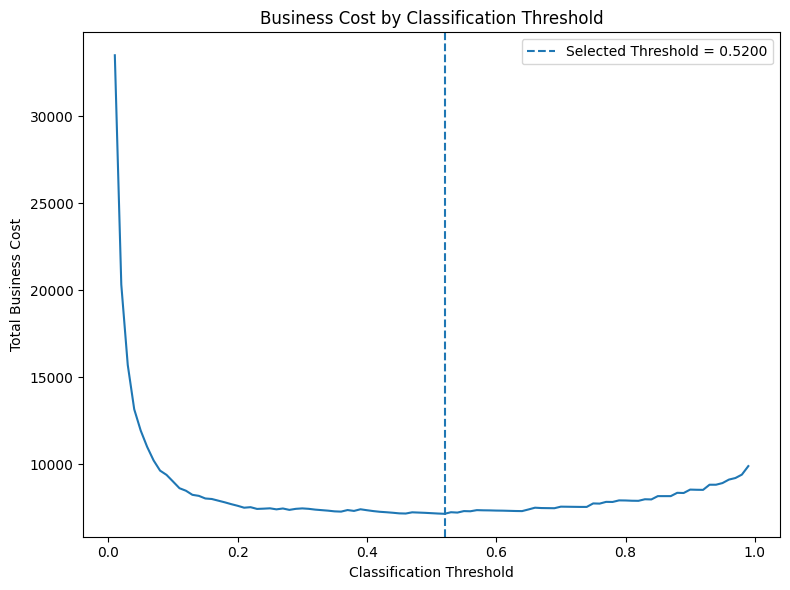

In [96]:
plt.figure(figsize=(8, 6))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Total Cost"]
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Selected Threshold = {best_threshold:.4f}"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Total Business Cost")
plt.title("Business Cost by Classification Threshold")
plt.legend()
plt.tight_layout()

plt.savefig(
    "../images/10_business_cost_by_threshold.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## False Positive and False Negative Trade-Off

The number of false positives and false negatives changes as the classification threshold changes.

This illustrates the practical trade-off between customer impact and missed fraud.

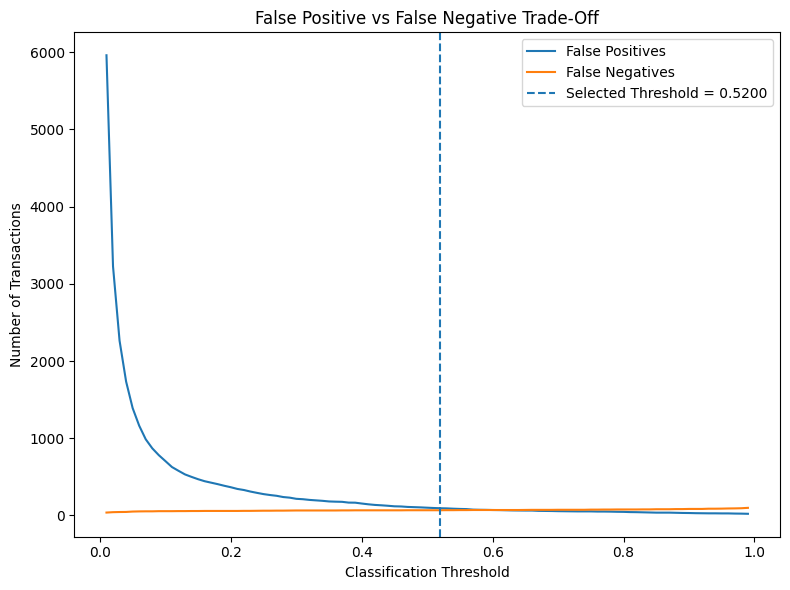

In [97]:
plt.figure(figsize=(8, 6))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["False Positives"],
    label="False Positives"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["False Negatives"],
    label="False Negatives"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Selected Threshold = {best_threshold:.4f}"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Number of Transactions")
plt.title("False Positive vs False Negative Trade-Off")
plt.legend()
plt.tight_layout()

plt.savefig(
    "../images/11_false_positive_false_negative_tradeoff.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Final Test Set Evaluation

The threshold was selected using out-of-fold predictions from the training data.

The test set was not used to choose the threshold.

The selected XGBoost model is now evaluated once on the untouched test set using the selected threshold.

In [98]:
best_model.fit(
    X_train,
    y_train
)

,steps,"[('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8


In [99]:
test_probabilities = best_model.predict_proba(
    X_test
)[:, 1]

In [100]:
test_predictions = (
    test_probabilities >= best_threshold
).astype(int)

In [101]:
tn, fp, fn, tp = confusion_matrix(
    y_test,
    test_predictions,
    labels=[0, 1]
).ravel()

test_precision = (
    tp / (tp + fp)
    if (tp + fp) > 0
    else 0
)

test_recall = (
    tp / (tp + fn)
    if (tp + fn) > 0
    else 0
)

test_f1 = (
    2 * test_precision * test_recall
    / (test_precision + test_recall)
    if (test_precision + test_recall) > 0
    else 0
)

test_cost = (
    fp * cost_false_positive
    + fn * cost_false_negative
)

print("Selected threshold:", round(best_threshold, 4))
print("Precision:", round(test_precision, 4))
print("Recall:", round(test_recall, 4))
print("F1-score:", round(test_f1, 4))
print("False positives:", fp)
print("False negatives:", fn)
print("Total business cost:", int(test_cost))

Selected threshold: 0.52
Precision: 0.6058
Recall: 0.8469
F1-score: 0.7064
False positives: 54
False negatives: 15
Total business cost: 1770


In [102]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)

test_roc_auc = roc_auc_score(
    y_test,
    test_probabilities
)

test_pr_auc = average_precision_score(
    y_test,
    test_probabilities
)

print("ROC-AUC:", round(test_roc_auc, 4))
print("PR-AUC:", round(test_pr_auc, 4))

ROC-AUC: 0.9812
PR-AUC: 0.8549


In [103]:
final_test_results = pd.DataFrame([{
    "Threshold": best_threshold,
    "Precision": test_precision,
    "Recall": test_recall,
    "F1": test_f1,
    "ROC-AUC": test_roc_auc,
    "PR-AUC": test_pr_auc,
    "False Positives": fp,
    "False Negatives": fn,
    "Total Cost": test_cost
}])

final_test_results.round(4)

,Threshold,Precision,Recall,F1,ROC-AUC,PR-AUC,False Positives,False Negatives,Total Cost
0,0.52,0.6058,0.8469,0.7064,0.9812,0.8549,54,15,1770


## Part 06 Findings

Threshold tuning was performed using out-of-fold XGBoost probabilities from the training data.

The threshold was selected using illustrative business costs of 100 cost units for a missed fraudulent transaction and 5 cost units for an incorrectly blocked legitimate transaction.

The selected operating threshold was 0.5200.

On the untouched test set, the selected threshold produced a precision of 0.6058, recall of 0.8469 and F1-score of 0.7064.

The final test-set ROC-AUC was 0.9812 and the PR-AUC was 0.8549.

The model produced 54 false positives and 15 false negatives on the test set.

Using the selected business cost assumptions, the total test-set cost was 1770 cost units.

The threshold demonstrates the trade-off between catching fraudulent transactions and limiting incorrect blocks of legitimate transactions.

The threshold was selected without using the test set, which was reserved for the final evaluation.

# Part 07 — Final Model Evaluation & Stakeholder Reporting

## Goal

This final stage evaluates the selected XGBoost fraud detection model at the chosen operating threshold.

The final results are summarized from both a model-performance and business perspective.

The main goals are to:

- evaluate the final model on the untouched test set
- show the final confusion matrix
- summarize the key performance metrics
- explain the business trade-offs
- document the main limitations
- prepare a short stakeholder report

## Final Model

The final model is the tuned XGBoost classifier selected during cross-validation.

The selected configuration was:

- `n_estimators = 200`
- `max_depth = 4`
- `learning_rate = 0.1`
- `subsample = 1.0`
- `colsample_bytree = 0.8`

The model uses the class-weighted approach selected during the imbalance strategy comparison.

The operating threshold was selected as `0.5200` using out-of-fold training probabilities and the illustrative business cost assumptions.

The test set was kept untouched until final evaluation.

## Final Confusion Matrix

The confusion matrix shows how the final model classified the transactions at the selected threshold.

It helps separate:

- legitimate transactions correctly identified as legitimate
- legitimate transactions incorrectly flagged as fraud
- fraudulent transactions incorrectly missed
- fraudulent transactions correctly identified as fraud

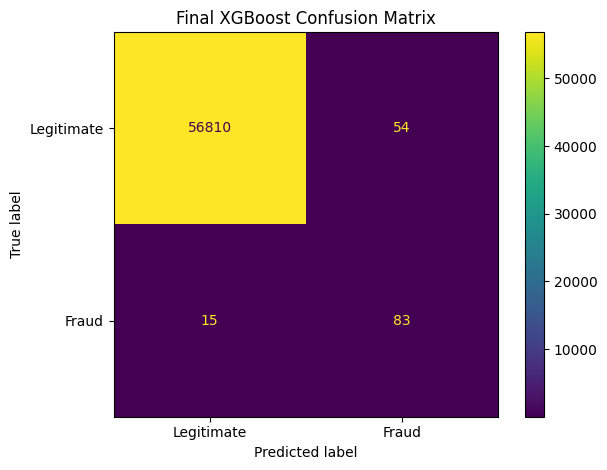

In [104]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    display_labels=["Legitimate", "Fraud"],
    values_format="d"
)

plt.title("Final XGBoost Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "../images/12_final_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Final Model Performance

The final model is summarized using precision, recall, F1-score, ROC-AUC and PR-AUC.

PR-AUC is especially important because the fraud class represents only a very small proportion of the dataset.

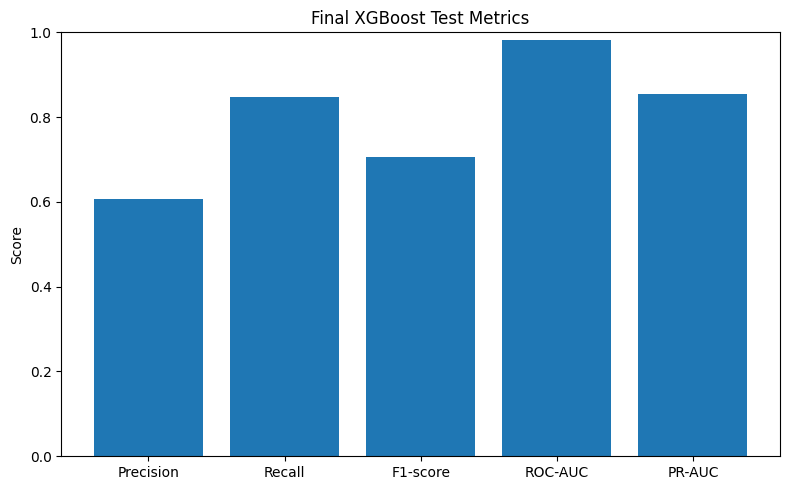

In [105]:
final_metrics = pd.DataFrame({
    "Metric": [
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Score": [
        test_precision,
        test_recall,
        test_f1,
        test_roc_auc,
        test_pr_auc
    ]
})

plt.figure(figsize=(8, 5))

plt.bar(
    final_metrics["Metric"],
    final_metrics["Score"]
)

plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Final XGBoost Test Metrics")

plt.tight_layout()

plt.savefig(
    "../images/13_final_test_metrics.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Final Test Results

The final model was evaluated once on the untouched test set using the selected operating threshold.

In [106]:
final_results = pd.DataFrame([{
    "Model": "Tuned XGBoost",
    "Threshold": best_threshold,
    "Precision": test_precision,
    "Recall": test_recall,
    "F1-score": test_f1,
    "ROC-AUC": test_roc_auc,
    "PR-AUC": test_pr_auc,
    "False Positives": fp,
    "False Negatives": fn,
    "Total Business Cost": test_cost
}])

final_results.round(4)

,Model,Threshold,Precision,Recall,F1-score,ROC-AUC,PR-AUC,False Positives,False Negatives,Total Business Cost
0,Tuned XGBoost,0.52,0.6058,0.8469,0.7064,0.9812,0.8549,54,15,1770


## Business Interpretation

The selected threshold of 0.5200 was chosen using illustrative costs of 100 cost units for a missed fraud and 5 cost units for an incorrectly blocked legitimate transaction.

At this threshold, the model achieved a recall of 0.8469 on the untouched test set, meaning that it identified most of the fraudulent transactions.

The model also produced 54 false positives. These represent legitimate transactions that would have been incorrectly flagged by the fraud detection system.

There were 15 false negatives, representing fraudulent transactions that were not detected.

The final business cost was 1770 cost units under the selected assumptions.

The results show that fraud detection is a balance between catching more fraud and reducing the number of legitimate customers incorrectly flagged.

## Limitations

This project has several limitations.

The business costs used for threshold selection are illustrative assumptions rather than actual costs from a financial institution.

The dataset contains anonymized features, so the analysis cannot explain which real-world transaction characteristics are associated with fraud.

The dataset is historical, so model performance may change when transaction patterns change over time.

The final threshold was selected using a simple cost framework with only two error costs. A real fraud detection system could also consider investigation costs, customer experience, account risk and downstream fraud losses.

The final model was evaluated on one held-out test set. Additional monitoring would be needed before deploying the model in production.

## Final Conclusion

The project showed why accuracy alone is misleading for highly imbalanced fraud detection problems.

Class weighting was the strongest of the three imbalance-handling strategies tested.

XGBoost performed better overall than Logistic Regression and remained the strongest model after hyperparameter tuning.

The tuned XGBoost model achieved a cross-validated PR-AUC of 0.8345 before threshold tuning.

After selecting the operating threshold based on business costs, the model achieved a test-set PR-AUC of 0.8549 and recall of 0.8469.

The final operating threshold of 0.5200 provides a practical balance between detecting fraudulent transactions and limiting incorrect blocks of legitimate transactions under the illustrative cost assumptions.

The complete workflow demonstrates leakage-safe preprocessing, imbalance handling, model comparison, hyperparameter tuning, threshold selection and business-focused evaluation.